<a href="https://colab.research.google.com/github/NandaKishore-04/Social-Media-Engagement-Analysis/blob/main/SocialMediaAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

# Better looking plots
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")


In [ ]:
df = pd.read_csv("/content/Social Media Engagement Dataset.csv")

In [ ]:
df.head(10)

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8
5,e8rzr949rzkr,2024-07-28 03:21:09,Sunday,Reddit,user_jzvf44eq,"Seoul, South Korea",pt,Nike PowerRelease is subpar! Can't wait to see...,#Discount,NaN,...,441,7734,0.64908,Nike,React,CyberMonday,Pre-Launch,0.9095,-0.4563,16.0
6,32qywmjy84gk,2024-08-21 17:02:47,Wednesday,Instagram,user_hpr07vl1,"Madrid, Spain",ja,Not sure why with my new Pepsi Wild Cherry fro...,"#Quality, #Promo, #Limited",NaN,...,974,24542,0.16139,Pepsi,Pepsi Wild Cherry,GlobalCampaign,Launch,-0.9263,-0.0810,-13.4
7,wu063ci6mizp,2025-01-27 16:09:54,Monday,Reddit,user_2es9a4lv,"São Paulo, Brazil",es,Just saw an ad for Coca-Cola Coke Zero during ...,"#MustHave, #Discount","@MarketingTeam, @InfluencerName",...,30,57406,0.04442,Coca-Cola,Coke Zero,CustomerFirst,Post-Launch,-0.9831,0.2152,89.7
8,9q2i3owe4tv9,2024-11-29 17:03:41,Friday,Reddit,user_omh7bn2t,"Milan, Italy",ru,Just tried the Coke Zero from Coca-Cola. Absol...,"#Deal, #Fashion",@TrendSetter,...,993,85296,0.03274,Coca-Cola,Coke Zero,SpringBlast2025,Launch,-0.8119,-0.1949,-29.0
9,gkyad7r8w6g5,2025-02-27 23:21:02,Thursday,YouTube,user_kp84hgj9,"Houston, USA",es,My one week review of Google Pixel Watch: Disa...,"#Tech, #SpecialOffer",@BrandSupport,...,820,61572,0.06759,Google,Pixel Watch,CyberMonday,Launch,-0.1217,0.1390,-56.6


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12000
Columns: 28


In [ ]:
df.columns

Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
       'location', 'language', 'text_content', 'hashtags', 'mentions',
       'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
       'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
       'comments_count', 'impressions', 'engagement_rate', 'brand_name',
       'product_name', 'campaign_name', 'campaign_phase',
       'user_past_sentiment_avg', 'user_engagement_growth',
       'buzz_change_rate'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  object 
 1   timestamp                12000 non-null  object 
 2   day_of_week              12000 non-null  object 
 3   platform                 12000 non-null  object 
 4   user_id                  12000 non-null  object 
 5   location                 12000 non-null  object 
 6   language                 12000 non-null  object 
 7   text_content             12000 non-null  object 
 8   hashtags                 12000 non-null  object 
 9   mentions                 8059 non-null   object 
 10  keywords                 12000 non-null  object 
 11  topic_category           12000 non-null  object 
 12  sentiment_score          12000 non-null  float64
 13  sentiment_label          12000 non-null  object 
 14  emotion_type          

In [ ]:
df.describe()

,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

mentions    3941
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   post_id                  12000 non-null  object        
 1   timestamp                12000 non-null  datetime64[ns]
 2   day_of_week              12000 non-null  object        
 3   platform                 12000 non-null  object        
 4   user_id                  12000 non-null  object        
 5   location                 12000 non-null  object        
 6   language                 12000 non-null  object        
 7   text_content             12000 non-null  object        
 8   hashtags                 12000 non-null  object        
 9   mentions                 8059 non-null   object        
 10  keywords                 12000 non-null  object        
 11  topic_category           12000 non-null  object        
 12  sentiment_score          12000 n

In [ ]:
df["month"] = df["timestamp"].dt.month_name()
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date
df["year"] = df["timestamp"].dt.year
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

In [ ]:
df["total_engagement"] = (
    df["likes_count"] +
    df["comments_count"] +
    df["shares_count"]
)

In [ ]:
df.to_csv("cleaned_social_media_data.csv", index=False)

platform
Instagram    4046.411890
Reddit       4007.652614
YouTube      4006.890805
Facebook     4003.503908
Twitter      3947.648379
Name: total_engagement, dtype: float64


/tmp/ipykernel_1257/1161808642.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


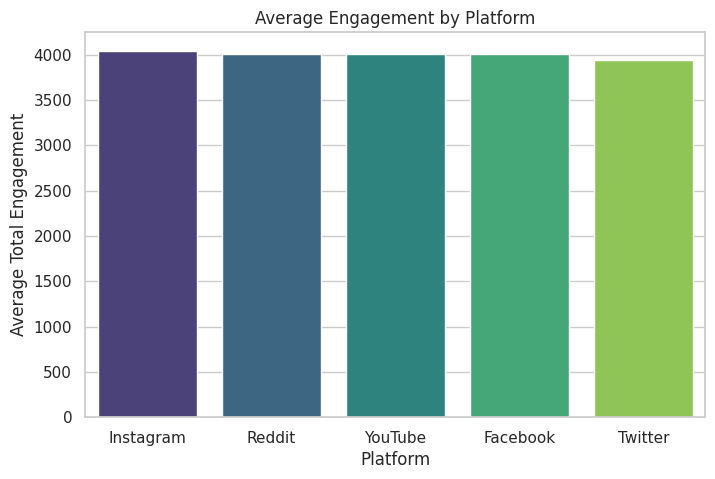

In [ ]:
platform_engagement = (
    df.groupby("platform")["total_engagement"]
      .mean()
      .sort_values(ascending=False)
)

print(platform_engagement)

plt.figure(figsize=(8,5))

sns.barplot(
    x=platform_engagement.index,
    y=platform_engagement.values,
    palette="viridis"
)

plt.title("Average Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Total Engagement")

plt.show()

/tmp/ipykernel_1257/772163513.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


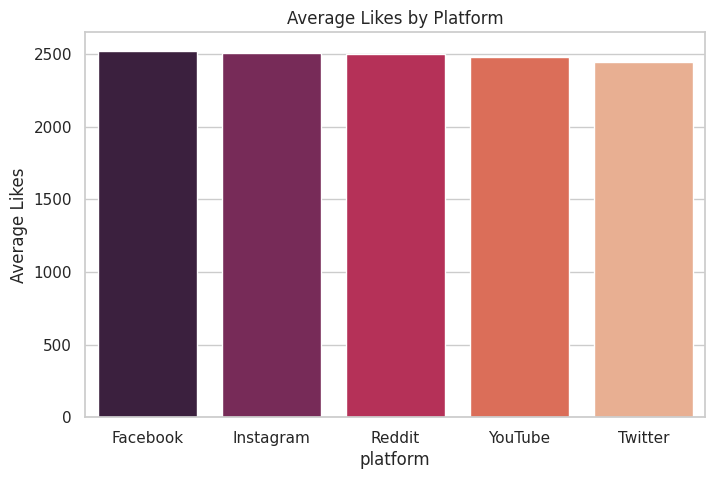

In [ ]:
likes = (
    df.groupby("platform")["likes_count"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=likes.index,
    y=likes.values,
    palette="rocket"
)

plt.title("Average Likes by Platform")
plt.ylabel("Average Likes")

plt.show()

/tmp/ipykernel_1257/517504346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


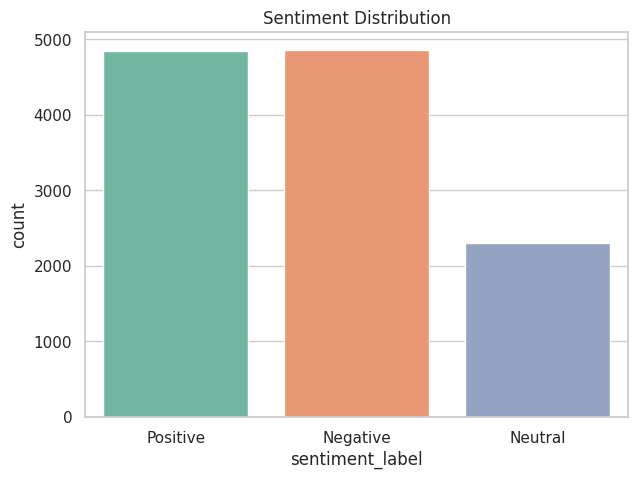

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sentiment_label",
    palette="Set2"
)

plt.title("Sentiment Distribution")

plt.show()

/tmp/ipykernel_1257/1163406722.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


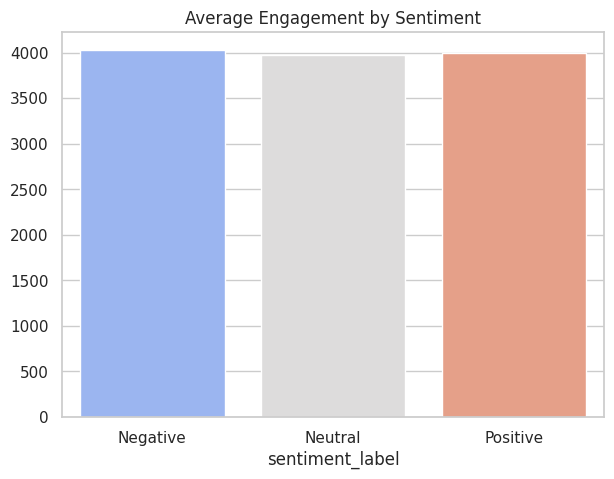

In [ ]:
sentiment = (
    df.groupby("sentiment_label")["total_engagement"]
      .mean()
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=sentiment.index,
    y=sentiment.values,
    palette="coolwarm"
)

plt.title("Average Engagement by Sentiment")

plt.show()

/tmp/ipykernel_1257/2797768264.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


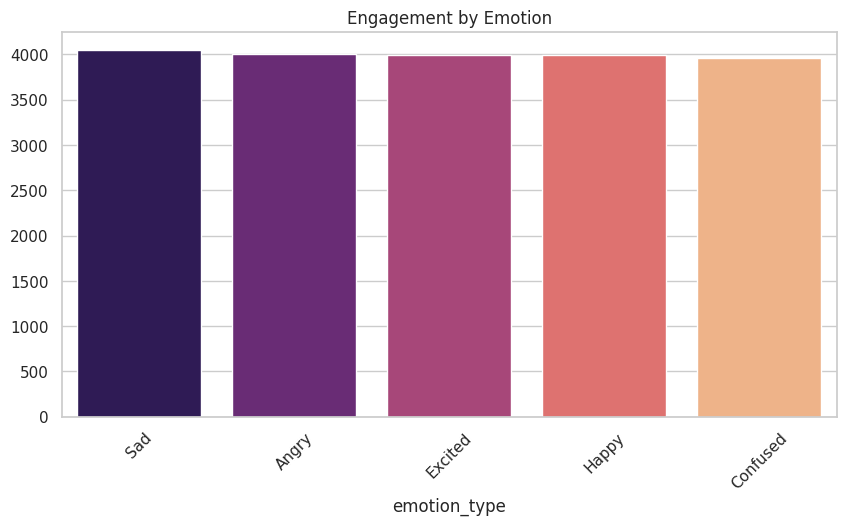

In [ ]:
emotion = (
    df.groupby("emotion_type")["total_engagement"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=emotion.index,
    y=emotion.values,
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Engagement by Emotion")

plt.show()

/tmp/ipykernel_1257/2228017382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


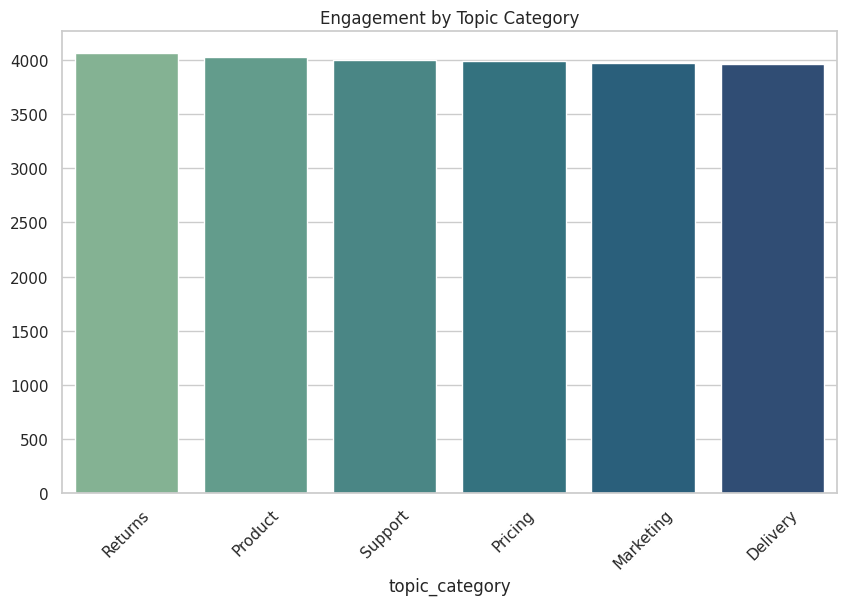

In [ ]:
topic = (
    df.groupby("topic_category")["total_engagement"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=topic.index,
    y=topic.values,
    palette="crest"
)

plt.xticks(rotation=45)

plt.title("Engagement by Topic Category")

plt.show()

/tmp/ipykernel_1257/1975186253.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


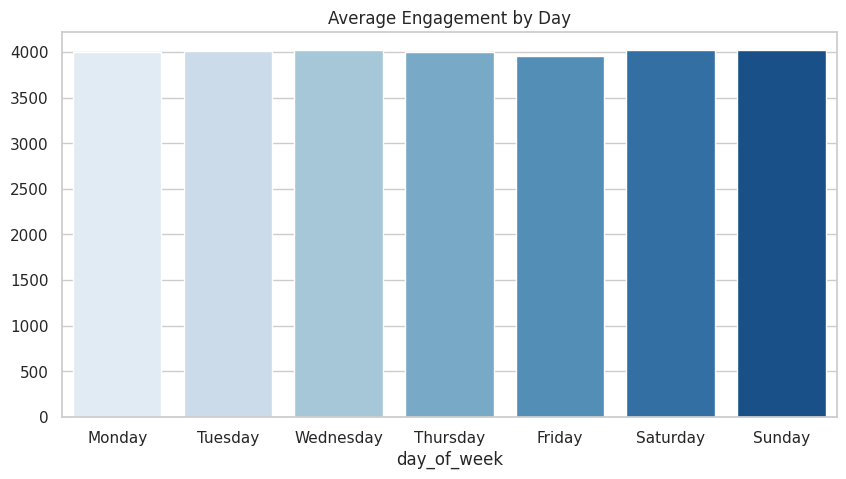

In [ ]:
day = (
    df.groupby("day_of_week")["total_engagement"]
      .mean()
)

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day = day.reindex(order)

plt.figure(figsize=(10,5))

sns.barplot(
    x=day.index,
    y=day.values,
    palette="Blues"
)

plt.title("Average Engagement by Day")

plt.show()

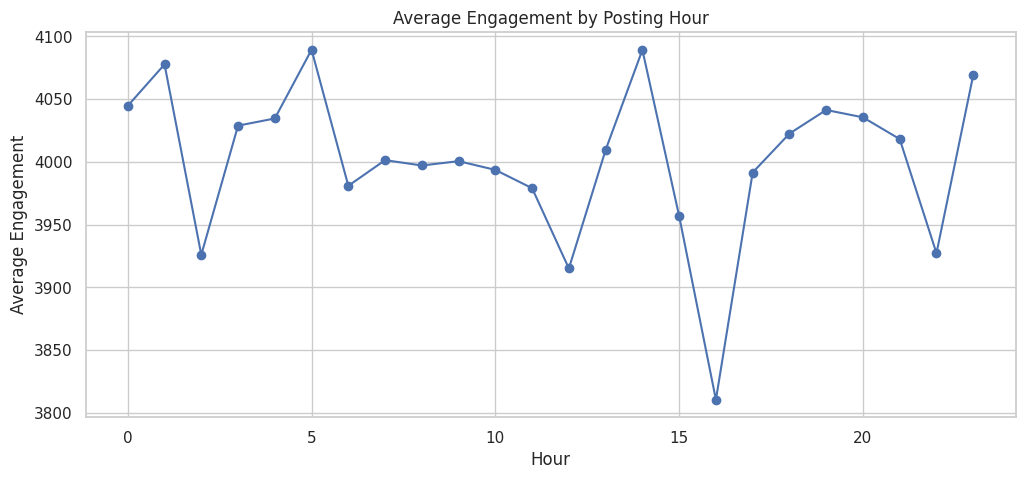

In [ ]:
hour = (
    df.groupby("hour")["total_engagement"]
      .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    hour.index,
    hour.values,
    marker="o"
)

plt.title("Average Engagement by Posting Hour")

plt.xlabel("Hour")

plt.ylabel("Average Engagement")

plt.grid(True)

plt.show()

/tmp/ipykernel_1257/2721739936.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


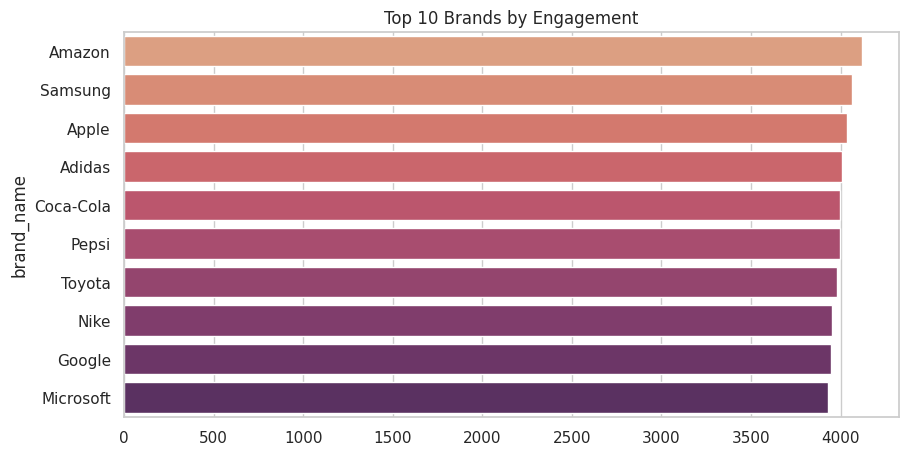

In [ ]:
brand = (
    df.groupby("brand_name")["total_engagement"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=brand.values,
    y=brand.index,
    palette="flare"
)

plt.title("Top 10 Brands by Engagement")

plt.show()

/tmp/ipykernel_1257/2408139805.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


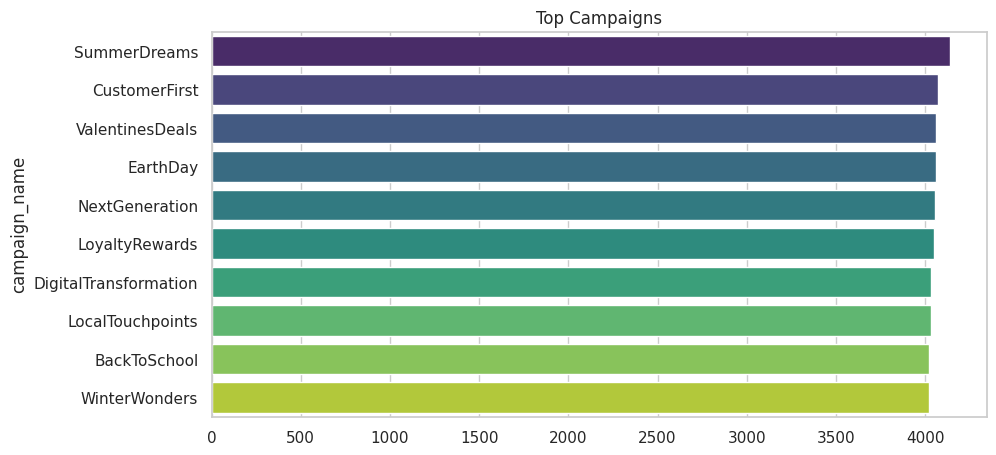

In [ ]:
campaign = (
    df.groupby("campaign_name")["total_engagement"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=campaign.values,
    y=campaign.index,
    palette="viridis"
)

plt.title("Top Campaigns")

plt.show()

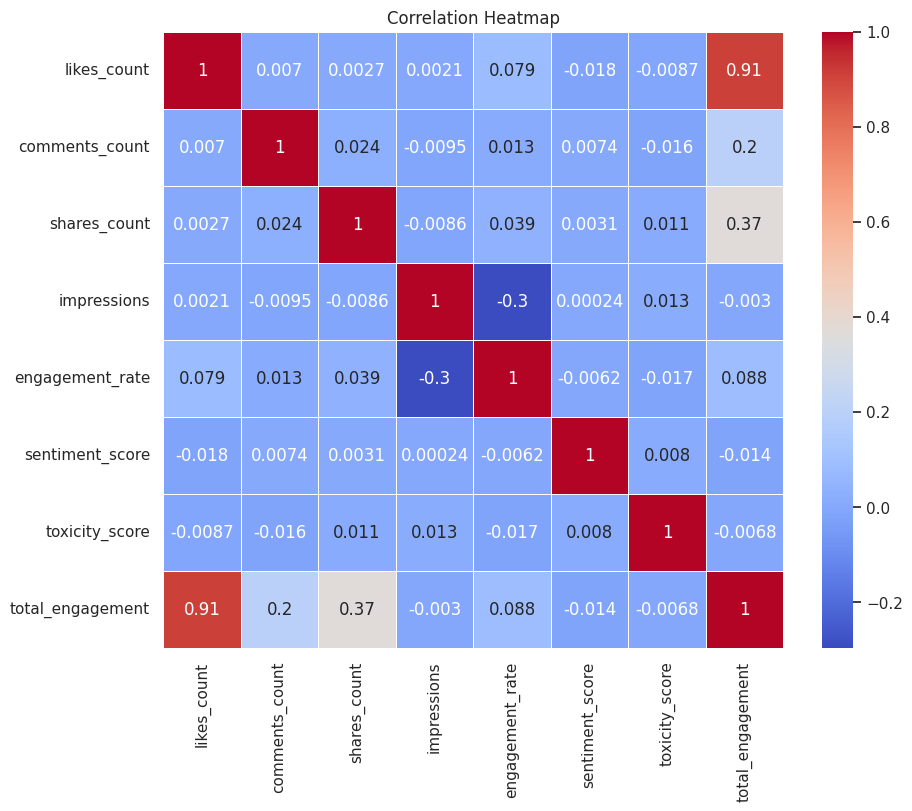

In [ ]:
corr = df[
    [
        "likes_count",
        "comments_count",
        "shares_count",
        "impressions",
        "engagement_rate",
        "sentiment_score",
        "toxicity_score",
        "total_engagement"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
top_posts = (
    df.sort_values("total_engagement", ascending=False)
      [["post_id",
        "platform",
        "topic_category",
        "total_engagement"]]
      .head(10)
)

print(top_posts)

            post_id   platform topic_category  total_engagement
459    7v5a8zyj4gw5    YouTube      Marketing              7900
11947  ycjj5zzt7mvx  Instagram        Returns              7893
8925   3dh1ecglz4bd     Reddit      Marketing              7817
3075   wo7py9aljg3t     Reddit      Marketing              7793
1770   gmoeib832zbs   Facebook        Product              7764
6899   5kvuyvf38nqx    YouTube      Marketing              7755
11154  pvfl3d8hj7jd  Instagram        Support              7738
4093   tdgjjylpua20    YouTube        Pricing              7723
3881   tne7s3o4l4wd  Instagram        Product              7712
6398   kwt9yuwjsw74    Twitter       Delivery              7685


In [ ]:
# Total Posts
total_posts = len(df)

# Total Likes
total_likes = df["likes_count"].sum()

# Total Comments
total_comments = df["comments_count"].sum()

# Total Shares
total_shares = df["shares_count"].sum()

# Total Impressions
total_impressions = df["impressions"].sum()

# Average Engagement
average_engagement = df["total_engagement"].mean()

# Average Engagement Rate
average_engagement_rate = df["engagement_rate"].mean()

print("Total Posts:", total_posts)
print("Total Likes:", total_likes)
print("Total Comments:", total_comments)
print("Total Shares:", total_shares)
print("Total Impressions:", total_impressions)
print("Average Engagement:", round(average_engagement,2))
print("Average Engagement Rate:", round(average_engagement_rate,2))

Total Posts: 12000
Total Likes: 29888643
Total Comments: 6052149
Total Shares: 12086006
Total Impressions: 597736062
Average Engagement: 4002.23
Average Engagement Rate: 0.28


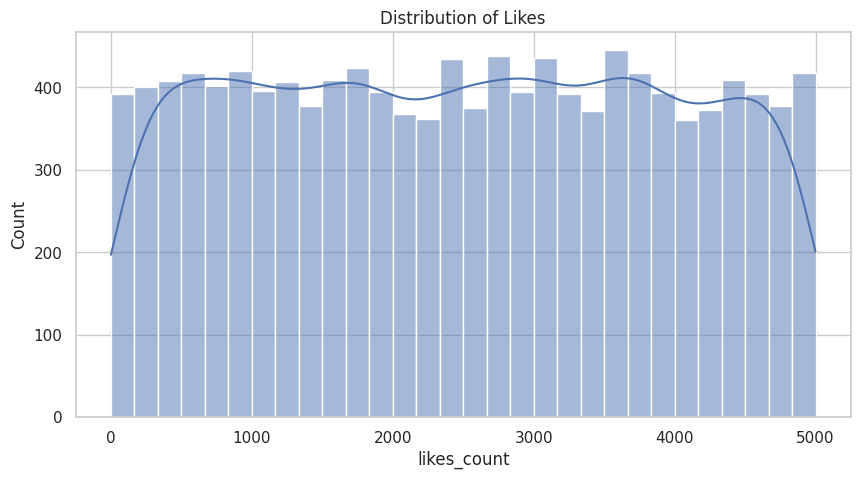

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["likes_count"], bins=30, kde=True)

plt.title("Distribution of Likes")

plt.show()

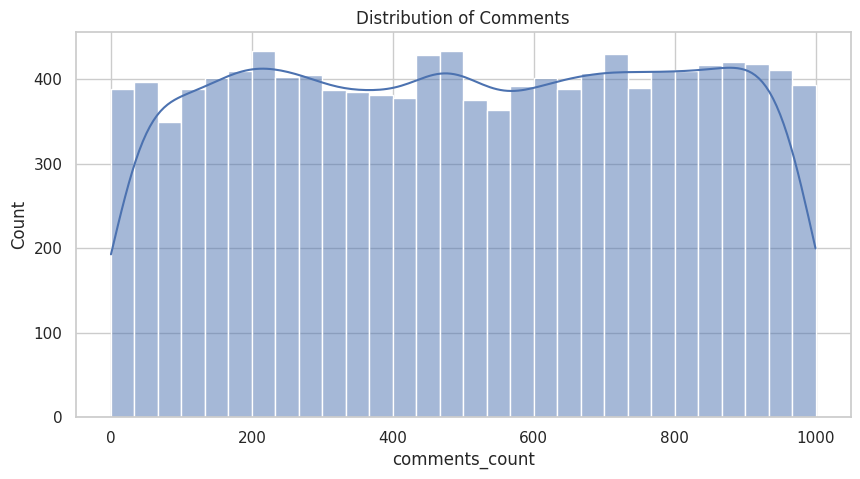

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["comments_count"], bins=30, kde=True)

plt.title("Distribution of Comments")

plt.show()

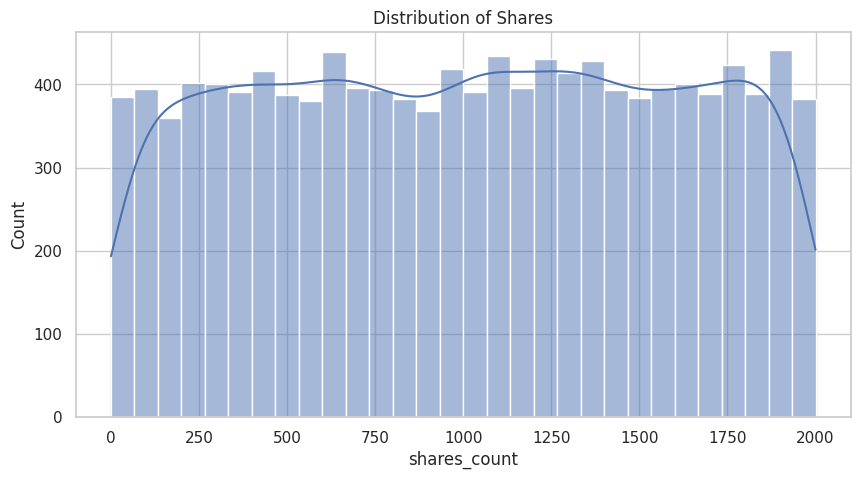

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["shares_count"], bins=30, kde=True)

plt.title("Distribution of Shares")

plt.show()

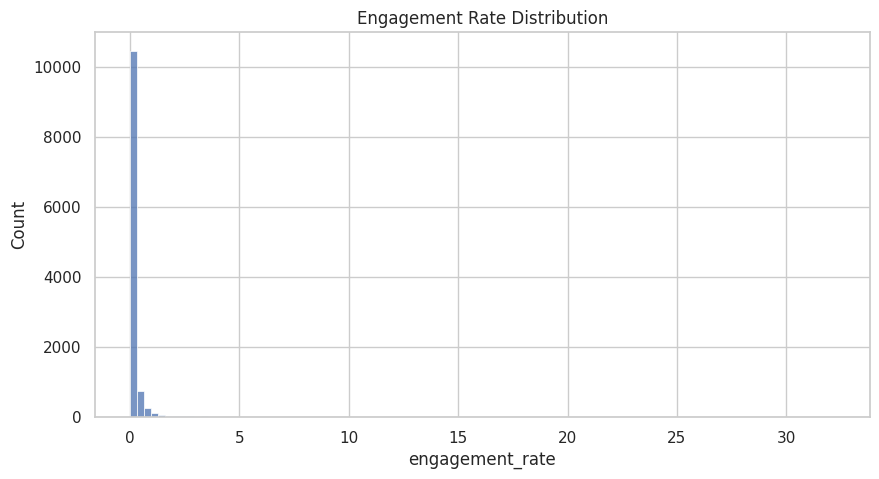

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["engagement_rate"], bins=100)

plt.title("Engagement Rate Distribution")

plt.show()

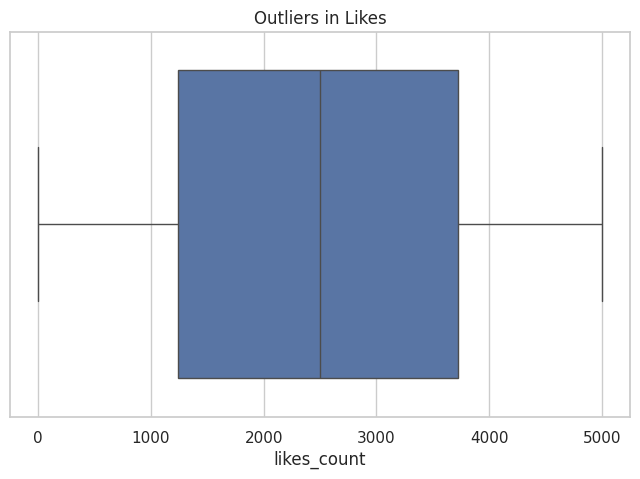

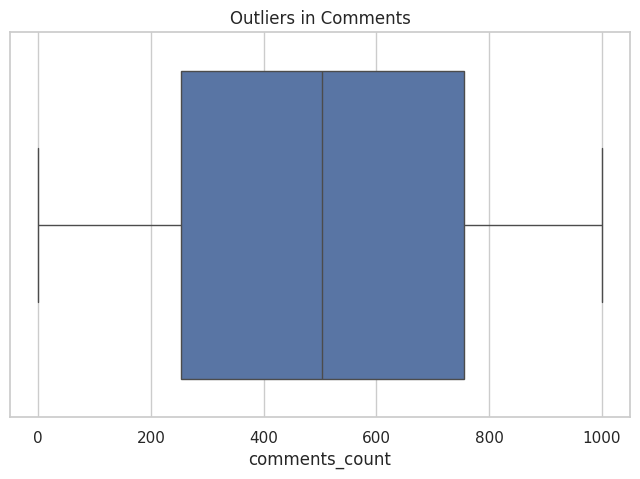

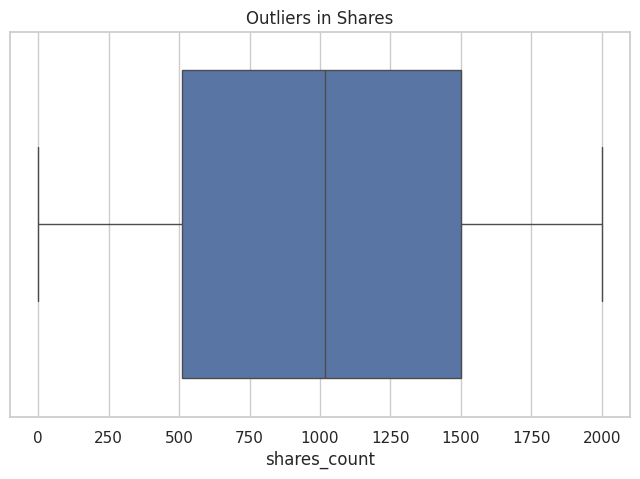

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["likes_count"])

plt.title("Outliers in Likes")

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(x=df["comments_count"])

plt.title("Outliers in Comments")

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(x=df["shares_count"])

plt.title("Outliers in Shares")

plt.show()

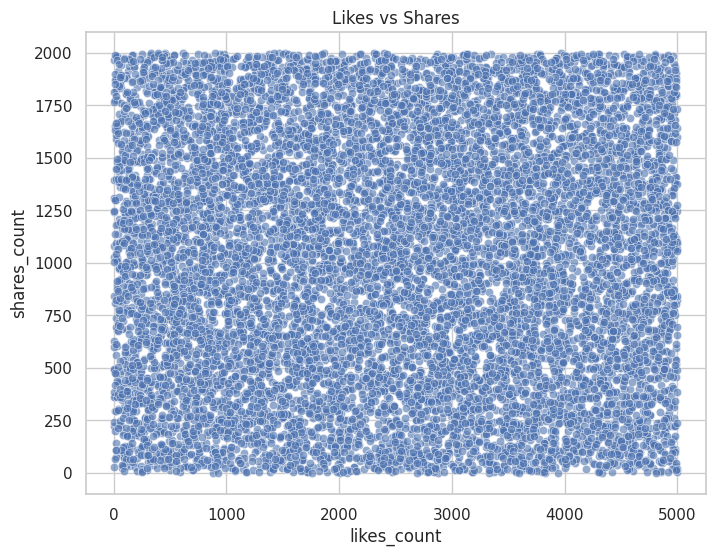

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="likes_count",
    y="shares_count",
    alpha=0.6
)

plt.title("Likes vs Shares")

plt.show()

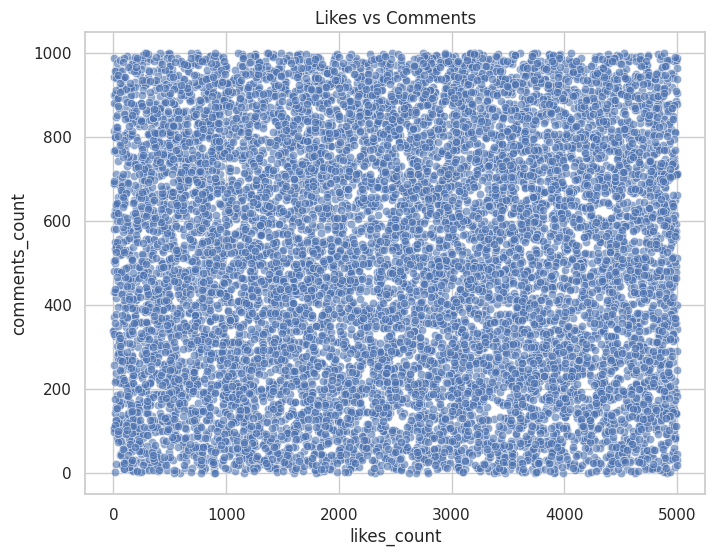

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="likes_count",
    y="comments_count",
    alpha=0.6
)

plt.title("Likes vs Comments")

plt.show()

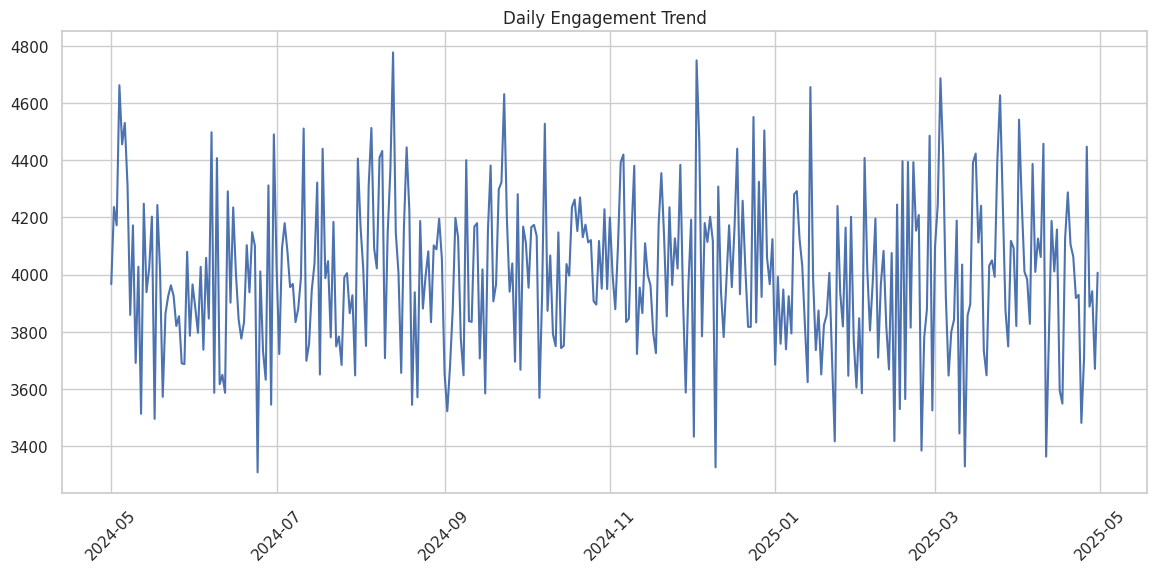

In [ ]:
daily = (
    df.groupby("date")["total_engagement"]
      .mean()
)

plt.figure(figsize=(14,6))

plt.plot(daily.index, daily.values)

plt.title("Daily Engagement Trend")

plt.xticks(rotation=45)

plt.show()

In [ ]:
top20 = (
    df.sort_values(
        "total_engagement",
        ascending=False
    ).head(20)
)

top20[
    [
        "post_id",
        "platform",
        "topic_category",
        "likes_count",
        "comments_count",
        "shares_count",
        "total_engagement"
    ]
]

,post_id,platform,topic_category,likes_count,comments_count,shares_count,total_engagement
459,7v5a8zyj4gw5,YouTube,Marketing,4963,950,1987,7900
11947,ycjj5zzt7mvx,Instagram,Returns,4983,991,1919,7893
8925,3dh1ecglz4bd,Reddit,Marketing,4913,983,1921,7817
3075,wo7py9aljg3t,Reddit,Marketing,4864,948,1981,7793
1770,gmoeib832zbs,Facebook,Product,4902,982,1880,7764
6899,5kvuyvf38nqx,YouTube,Marketing,4923,861,1971,7755
11154,pvfl3d8hj7jd,Instagram,Support,4989,909,1840,7738
4093,tdgjjylpua20,YouTube,Pricing,4979,812,1932,7723
3881,tne7s3o4l4wd,Instagram,Product,4931,878,1903,7712
6398,kwt9yuwjsw74,Twitter,Delivery,4914,928,1843,7685


In [ ]:
highest_platform = (
    df.groupby("platform")["total_engagement"]
      .mean()
      .idxmax()
)

best_topic = (
    df.groupby("topic_category")["total_engagement"]
      .mean()
      .idxmax()
)

best_day = (
    df.groupby("day_of_week")["total_engagement"]
      .mean()
      .idxmax()
)

best_brand = (
    df.groupby("brand_name")["total_engagement"]
      .mean()
      .idxmax()
)

print("Best Platform :", highest_platform)
print("Best Topic :", best_topic)
print("Best Day :", best_day)
print("Best Brand :", best_brand)

Best Platform : Instagram
Best Topic : Returns
Best Day : Sunday
Best Brand : Amazon
